In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import polars as pl
import numpy as np
import seaborn as sns

In [6]:
G = nx.Graph()
df_nodes = pl.read_csv("buses.csv")
G.add_nodes_from(df_nodes["bus_id"])
df_edges1 = pl.read_csv("lines.csv", separator=",", truncate_ragged_lines=True)
G.add_edges_from(df_edges1[["bus0", "bus1"]].rows())
df_edges2 = pl.read_csv("links.csv", separator=",", truncate_ragged_lines=True)
G.add_edges_from(df_edges2[["bus0", "bus1"]].rows())
df_edges3 = pl.read_csv("transformers.csv", separator=",", truncate_ragged_lines=True)
G.add_edges_from(df_edges3[["bus0", "bus1"]].rows())
df_edges4 = pl.read_csv("converters.csv", separator=",", truncate_ragged_lines=True)
G.add_edges_from(df_edges4[["bus0", "bus1"]].rows())

pos = {}
for row in df_nodes.iter_rows():
    idx = row[0]
    x = row[6]
    y = row[7]
    pos[idx] = [x, y]

europe = gpd.read_file("european_map.json")

(35.0, 72.0)

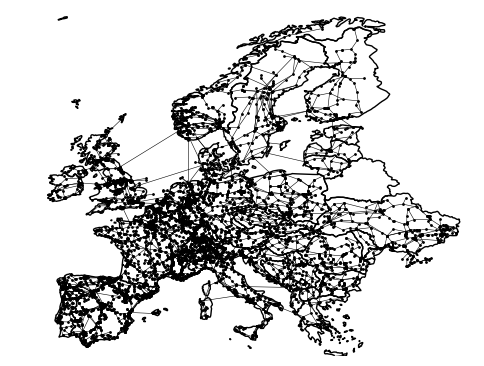

In [7]:
plt.figure(figsize=(6, 6))
ax = plt.gca()
nx.draw(
    G,
    ax=ax,
    pos=pos,
    node_size=1,
    width=0.4,
    node_color="black",
)
europe.plot(facecolor="None", ax=ax)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim([-15, 42])
plt.ylim([35, 72])

## The robustness of the European power grid

In [8]:
realizations = 10
fractions = np.linspace(0, 0.9, 20)

In [9]:
gcc_data = np.zeros((len(fractions), realizations))
for i, f in enumerate(fractions):
    for r in range(realizations):
        G_temp = G.copy()
        n_remove = int(f * G.number_of_nodes())
        nodes_remove = np.random.choice(G_temp.nodes(), size=n_remove, replace=False)
        G_temp.remove_nodes_from(nodes_remove)

        gcc_data[i, r] = len(max(nx.connected_components(G_temp), key=len)) / G_temp.number_of_nodes()

In [10]:
p = nx.density(G)

gcc_er = np.zeros((len(fractions), realizations))
for i, f in enumerate(fractions):
    for r in range(realizations):
        G_temp = nx.fast_gnp_random_graph(G.number_of_nodes(), p)
        n_remove = int(f * G.number_of_nodes())
        nodes_remove = np.random.choice(G_temp.nodes(), size=n_remove, replace=False)
        G_temp.remove_nodes_from(nodes_remove)

        gcc_er[i, r] = len(max(nx.connected_components(G_temp), key=len)) / G_temp.number_of_nodes()

In [11]:
m = int(G.number_of_edges() / G.number_of_nodes())

gcc_pa = np.zeros((len(fractions), realizations))
for i, f in enumerate(fractions):
    for r in range(realizations):
        G_temp = nx.barabasi_albert_graph(G.number_of_nodes(), m)
        n_remove = int(f * G.number_of_nodes())
        nodes_remove = np.random.choice(G_temp.nodes(), size=n_remove, replace=False)
        G_temp.remove_nodes_from(nodes_remove)

        gcc_pa[i, r] = len(max(nx.connected_components(G_temp), key=len)) / G_temp.number_of_nodes()

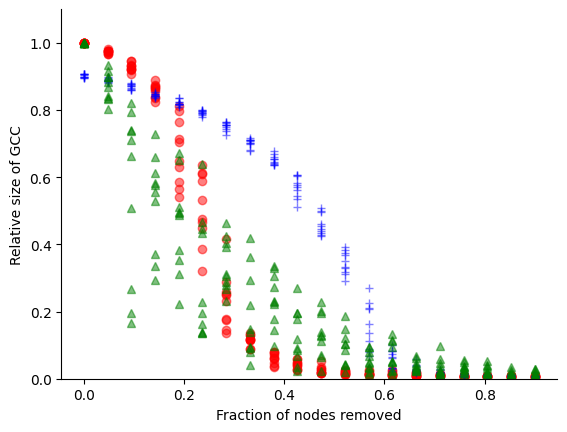

In [23]:
plt.plot(fractions, gcc_data, "o", color="red", alpha=0.5)
plt.plot(fractions, gcc_er, "+", color="blue", alpha=0.5)
plt.plot(fractions, gcc_pa, "^", color="green", alpha=0.5)
plt.xlabel("Fraction of nodes removed")
plt.ylabel("Relative size of GCC")
plt.ylim([0, 1.1])
sns.despine()

## Most influential nodes

In [13]:
bc = nx.betweenness_centrality(G)
dc = nx.degree_centrality(G)
ec = nx.eigenvector_centrality(G)

In [14]:
bc_sorted = sorted(bc.items(), key=lambda x: x[1], reverse=True)
dc_sorted = sorted(dc.items(), key=lambda x: x[1], reverse=True)
ec_sorted = sorted(ec.items(), key=lambda x: x[1], reverse=True)

(35.0, 72.0)

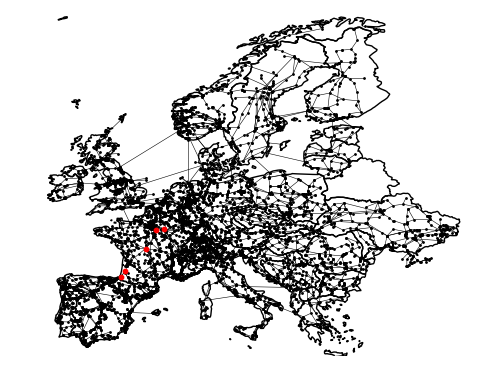

In [15]:
num_most_central = 5
plt.figure(figsize=(6, 6))
ax = plt.gca()
nx.draw(
    G,
    ax=ax,
    pos=pos,
    node_size=1,
    width=0.4,
    node_color="black",
)
europe.plot(facecolor="None", ax=ax)
x = [pos[bc_sorted[i][0]][0] for i in range(num_most_central)]
y = [pos[bc_sorted[i][0]][1] for i in range(num_most_central)]
plt.scatter(x, y, color='red', s=10, zorder=10000)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim([-15, 42])
plt.ylim([35, 72])

(35.0, 72.0)

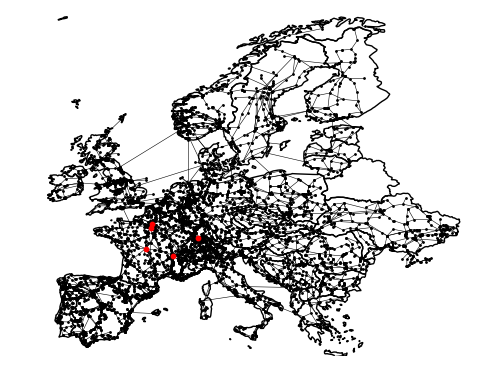

In [16]:
num_most_central = 5
plt.figure(figsize=(6, 6))
ax = plt.gca()
nx.draw(
    G,
    ax=ax,
    pos=pos,
    node_size=1,
    width=0.4,
    node_color="black",
)
europe.plot(facecolor="None", ax=ax)
x = [pos[dc_sorted[i][0]][0] for i in range(num_most_central)]
y = [pos[dc_sorted[i][0]][1] for i in range(num_most_central)]
plt.scatter(x, y, color='red', s=10, zorder=10000)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim([-15, 42])
plt.ylim([35, 72])

(35.0, 72.0)

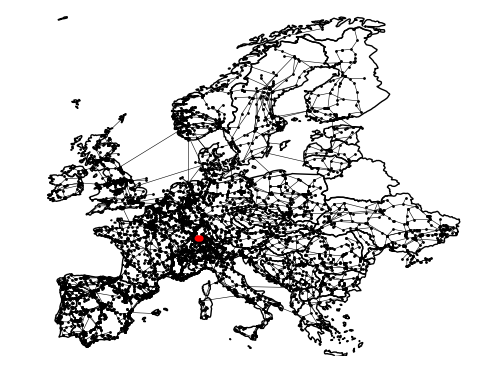

In [17]:
num_most_central = 5
plt.figure(figsize=(6, 6))
ax = plt.gca()
nx.draw(
    G,
    ax=ax,
    pos=pos,
    node_size=1,
    width=0.4,
    node_color="black",
)
europe.plot(facecolor="None", ax=ax)
x = [pos[ec_sorted[i][0]][0] for i in range(num_most_central)]
y = [pos[ec_sorted[i][0]][1] for i in range(num_most_central)]
plt.scatter(x, y, color='red', s=10, zorder=10000)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim([-15, 42])
plt.ylim([35, 72])

In [26]:
# Creating an interactive HTML map of the 2025 Iberian Peninsula Blackout events.
# The map will be saved to /mnt/data/iberian_blackout_2025_map.html for you to download.
# Uses folium to create an interactive map with color-coded markers and popups.

import folium
from folium.plugins import MarkerCluster
import os

# Map center (Iberian Peninsula)
m = folium.Map(location=[40.0, -4.0], zoom_start=6, control_scale=True)

# Events with approximate coordinates, time, description, and status
events = [
    {"time":"12:03 – 12:07 CEST", "desc":"First oscillations detected and mitigated.", "loc":"Iberian grid (widespread)", "coords":[40.0, -4.0], "status":"instability"},
    {"time":"12:19 – 12:21 CEST", "desc":"Second oscillations detected and mitigated.", "loc":"Spain & Portugal", "coords":[39.5, -3.5], "status":"instability"},
    {"time":"12:32:57 – 12:33:17 CEST", "desc":"Generation trips (loss of ~2200 MW).", "loc":"Granada", "coords":[37.1773, -3.5986], "status":"generation_trip"},
    {"time":"12:32:57 – 12:33:17 CEST", "desc":"Generation trips (loss of ~2200 MW).", "loc":"Badajoz", "coords":[38.8794, -6.9707], "status":"generation_trip"},
    {"time":"12:32:57 – 12:33:17 CEST", "desc":"Generation trips (loss of ~2200 MW).", "loc":"Seville", "coords":[37.3891, -5.9845], "status":"generation_trip"},
    {"time":"12:33:18 – 12:33:21 CEST", "desc":"Grid frequency drops below 48.0 Hz — automatic load shedding activated.", "loc":"Iberian Peninsula", "coords":[40.0, -4.0], "status":"load_shedding"},
    {"time":"12:33:21 CEST", "desc":"AC transmission lines between France and Spain trip.", "loc":"Pyrenees / France–Spain border", "coords":[42.8, 0.0], "status":"line_trip"},
    {"time":"12:33:24 CEST", "desc":"Complete grid collapse; HVDC link between France and Spain trips.", "loc":"Iberian Peninsula (HVDC Baixas–Santa Llogaia)", "coords":[42.4, 2.8], "status":"collapse"},
    {"time":"12:44 CEST", "desc":"First 400 kV Spain–France AC line re-energized.", "loc":"Northern Spain (Basque region)", "coords":[43.3, -2.9], "status":"reenergize"},
    {"time":"13:04 CEST", "desc":"Spain–Morocco interconnect re-energized.", "loc":"Tarifa (Cádiz)", "coords":[36.0140, -5.6050], "status":"reenergize"},
    {"time":"~13:30 CEST", "desc":"Spanish hydro power plants with black start capability begin procedures.", "loc":"Representative - Northern Spain (approx.)", "coords":[42.5, -1.5], "status":"black_start"},
    {"time":"13:35 CEST", "desc":"Eastern Spain–France AC line re-energized.", "loc":"Catalonia (near Barcelona)", "coords":[41.3851, 2.1734], "status":"reenergize"},
    {"time":"16:11 CEST", "desc":"First black-start capable power plant in Portugal starts.", "loc":"Northern Portugal (Porto region)", "coords":[41.1579, -8.6291], "status":"black_start"},
    {"time":"17:26 CEST", "desc":"Second black-start capable power plant in Portugal starts.", "loc":"Central Portugal (Coimbra region)", "coords":[40.2033, -8.4103], "status":"black_start"},
    {"time":"18:36 CEST", "desc":"220 kV line between Spain and Portugal re-energized.", "loc":"Salamanca–Bragança border region", "coords":[41.3, -6.2], "status":"reenergize"},
    {"time":"21:35 CEST", "desc":"400 kV line between Spain and southern Portugal re-energized.", "loc":"Alentejo–Extremadura corridor (Mérida area)", "coords":[38.9167, -6.3333], "status":"reenergize"},
    {"time":"00:22 CEST (next day)", "desc":"Grid fully restored in Portugal.", "loc":"Portugal (representative - Lisbon)", "coords":[38.7223, -9.1393], "status":"restored"},
    {"time":"04:00 CEST (next day)", "desc":"Grid fully restored in Spain.", "loc":"Spain (representative - Madrid)", "coords":[40.4168, -3.7038], "status":"restored"},
]

# color mapping by status
color_map = {
    "instability": "orange",
    "generation_trip": "red",
    "load_shedding": "darkred",
    "line_trip": "purple",
    "collapse": "black",
    "reenergize": "blue",
    "black_start": "cadetblue",
    "restored": "green"
}

# Add markers clustered
marker_cluster = MarkerCluster().add_to(m)

for ev in events:
    color = color_map.get(ev["status"], "gray")
    popup_html = f"<b>{ev['time']}</b><br><b>{ev['loc']}</b><br>{ev['desc']}"
    folium.CircleMarker(
        location=ev["coords"],
        radius=7,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.9,
        popup=folium.Popup(popup_html, max_width=300)
    ).add_to(marker_cluster)

# Add a simple legend (HTML)
legend_html = """
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 220px; height: 240px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white; opacity: 0.9; padding: 10px;">
<b>Legend — Event Status</b><br>
&nbsp;<i>instability</i> &nbsp; <span style="color:orange">●</span> Oscillations detected<br>
&nbsp;<i>generation_trip</i> &nbsp; <span style="color:red">●</span> Generation trips (loss)<br>
&nbsp;<i>load_shedding</i> &nbsp; <span style="color:darkred">●</span> Frequency drop / load shed<br>
&nbsp;<i>line_trip</i> &nbsp; <span style="color:purple">●</span> AC transmission trip<br>
&nbsp;<i>collapse</i> &nbsp; <span style="color:black">●</span> Grid collapse / HVDC trip<br>
&nbsp;<i>reenergize</i> &nbsp; <span style="color:blue">●</span> Re-energisation of lines/interconnects<br>
&nbsp;<i>black_start</i> &nbsp; <span style="color:cadetblue">●</span> Black-start procedures<br>
&nbsp;<i>restored</i> &nbsp; <span style="color:green">●</span> Grid fully restored<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save to HTML
out_path = "iberian_blackout_2025_map.html"
m.save(out_path)

# Confirm output path for the user to download
out_path, os.path.exists(out_path)




('iberian_blackout_2025_map.html', True)